In [19]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [20]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]

# (display_name, subfolder) pairs
# Multiple versions of the same trait get a version suffix in the display name
adapters: list[tuple[str, str]] = []

def add_ocean_adapters(version: str, label: str | None = None):
    """Add a full set of OCEAN adapters for a given version.

    Args:
        version: Version string used in the HF path (e.g. "vanton1", "v2").
        label: Display label suffix. If None, no suffix is added.
    """
    suffix = f"_{label}" if label else ""
    for trait in OCEAN_TRAITS:
        for direction, direction_verb, sign in DIRECTIONS:
            display = f"{trait}{sign}{suffix}"
            subfolder = (
                f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{version}/lora/"
                f"{trait}_{direction_verb}_full_{version}-persona"
            )
            adapters.append((display, subfolder))

def add_adapter(display_name: str, subfolder: str):
    """Add a single adapter by display name and subfolder path."""
    adapters.append((display_name, subfolder))

# OCEAN adapters — vanton1
add_ocean_adapters("vanton1", label="vanton1")

# Extra individual adapters
add_adapter(
    "agreeableness-_v2",
    "fine_tuning/llama-3.1-8b-it/ocean/agreeableness/suppressor/v2/lora/agreeableness_low-persona",
)

# Control adapters
add_adapter(
    "control",
    "fine_tuning/llama-3.1-8b-it/other/control-empty-traits/amplifier/v1/lora/control-persona",
)

In [21]:
import os
import sys
import time
from pathlib import Path
import requests

CACHE_DIR = Path("scratch/lora_cache")
HF_TOKEN = os.getenv("HF_TOKEN")

def _cache_path(subfolder: str, rank: int | None) -> Path:
    key = subfolder.replace("/", "__")
    if rank is not None:
        key += f"__rank{rank}"
    return CACHE_DIR / key

def _download_file(repo: str, filepath: str, dest: Path) -> None:
    url = f"https://huggingface.co/datasets/{repo}/resolve/main/{filepath}"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

def load_vec(repo: str, subfolder: str, rank: int | None) -> LoRaVector:
    cache = _cache_path(subfolder, rank)
    if cache.exists():
        return LoRaVector.from_file(cache).to(device="cuda")
    staging = CACHE_DIR / "_raw" / subfolder.replace("/", "__")
    for fname in ("adapter_config.json", "adapter_model.safetensors"):
        target = staging / fname
        if not target.exists():
            _download_file(repo, f"{subfolder}/{fname}", target)
    vec = LoRaVector.from_file(staging).to(device="cuda")
    if rank is not None:
        vec = vec.rank_reduce(rank)
    cache.mkdir(parents=True, exist_ok=True)
    vec.to_file(cache)
    return vec

# Load persona adapters from HuggingFace (cached locally in scratch/lora_cache/)
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    print(name, flush=True)
    persona_vectors[name] = load_vec(REPO, subfolder, NEW_RANK)

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
# for dist in ["gaussian", "uniform", "zipf"]:
for dist in ["gaussian", "uniform"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/12 [00:00<?, ?it/s]

openness+_vanton1
openness-_vanton1
conscientiousness+_vanton1
conscientiousness-_vanton1


 33%|███▎      | 4/12 [00:00<00:00, 31.56it/s]

extraversion+_vanton1
extraversion-_vanton1
agreeableness+_vanton1
agreeableness-_vanton1


 67%|██████▋   | 8/12 [00:00<00:00, 34.01it/s]

neuroticism+_vanton1
neuroticism-_vanton1
agreeableness-_v2


 92%|█████████▏| 11/12 [00:37<00:04,  4.87s/it]

control


100%|██████████| 12/12 [00:37<00:00,  3.16s/it]


In [22]:
for name, vec in persona_vectors.items():
    print(f"{name:20s} {vec.norm:.4f}")


openness+_vanton1    2.8472
openness-_vanton1    2.7764
conscientiousness+_vanton1 2.9019
conscientiousness-_vanton1 2.5940
extraversion+_vanton1 2.6546
extraversion-_vanton1 2.7928
agreeableness+_vanton1 2.9045
agreeableness-_vanton1 2.8740
neuroticism+_vanton1 2.7329
neuroticism-_vanton1 2.8747
agreeableness-_v2    2.7626
control              2.4299
base                 0.0000


In [23]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 10.66% Cumulative 10.66%
  PC1: 9.64% Cumulative 20.30%
  PC2: 9.57% Cumulative 29.87%
  PC3: 9.29% Cumulative 39.15%
  PC4: 9.04% Cumulative 48.19%
  PC5: 8.92% Cumulative 57.11%
  PC6: 8.91% Cumulative 66.01%
  PC7: 8.50% Cumulative 74.51%
  PC8: 7.97% Cumulative 82.48%
  PC9: 7.87% Cumulative 90.35%
  PC10: 7.62% Cumulative 97.97%
  PC11: 2.03% Cumulative 100.00%


In [24]:
import plotly.graph_objects as go

# Re-pull from pca_result so this cell is self-contained
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

# Color each OCEAN trait consistently across +/- pairs
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}

def persona_color(name: str) -> str | None:
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem)

# Amplifier (+) = filled circle, suppressor (-) = open circle
def persona_symbol(name: str) -> str:
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(13, 12), explained.shape=(12,)


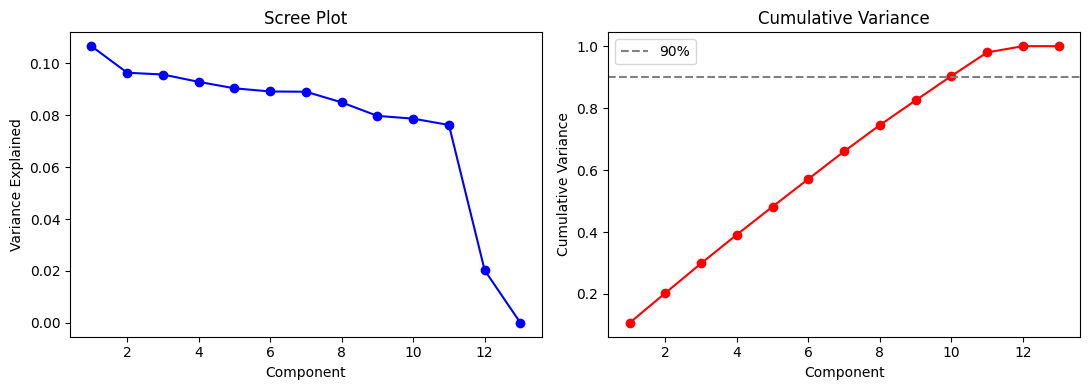

In [25]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC11 and PC12 (gap=4.0780)
  → suggests retaining 11 components
Effective rank: 11.52
Participation ratio: 11.30
Spectral entropy: 0.984 (0=concentrated, 1=diffuse)


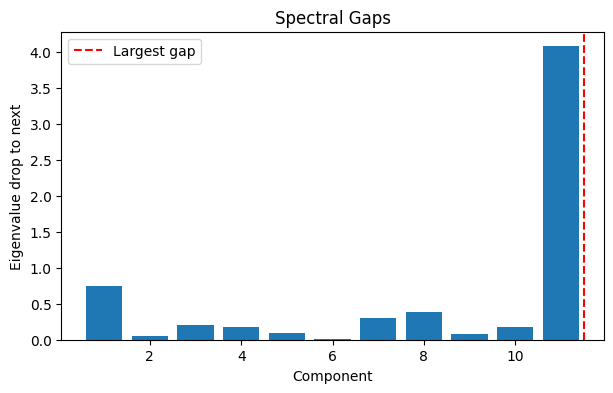

In [26]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

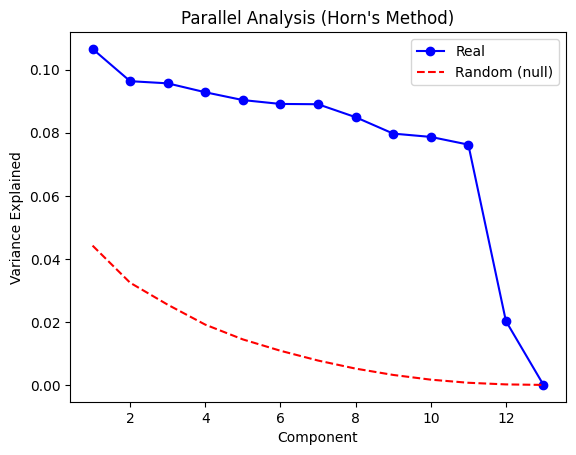

Retain 12 components by Horn's criterion


In [27]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [28]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

                            openness+_vanton1  openness-_vanton1  \
openness+_vanton1                       1.000              0.159   
openness-_vanton1                       0.159              1.000   
conscientiousness+_vanton1              0.172              0.118   
conscientiousness-_vanton1              0.155              0.126   
extraversion+_vanton1                   0.216              0.129   
extraversion-_vanton1                   0.158              0.157   
agreeableness+_vanton1                  0.210              0.148   
agreeableness-_vanton1                  0.151              0.149   
neuroticism+_vanton1                    0.197              0.141   
neuroticism-_vanton1                    0.175              0.158   
agreeableness-_v2                       0.166              0.137   
control                                 0.116              0.096   
base                                    0.000              0.000   
gaussian_0                             -0.000   

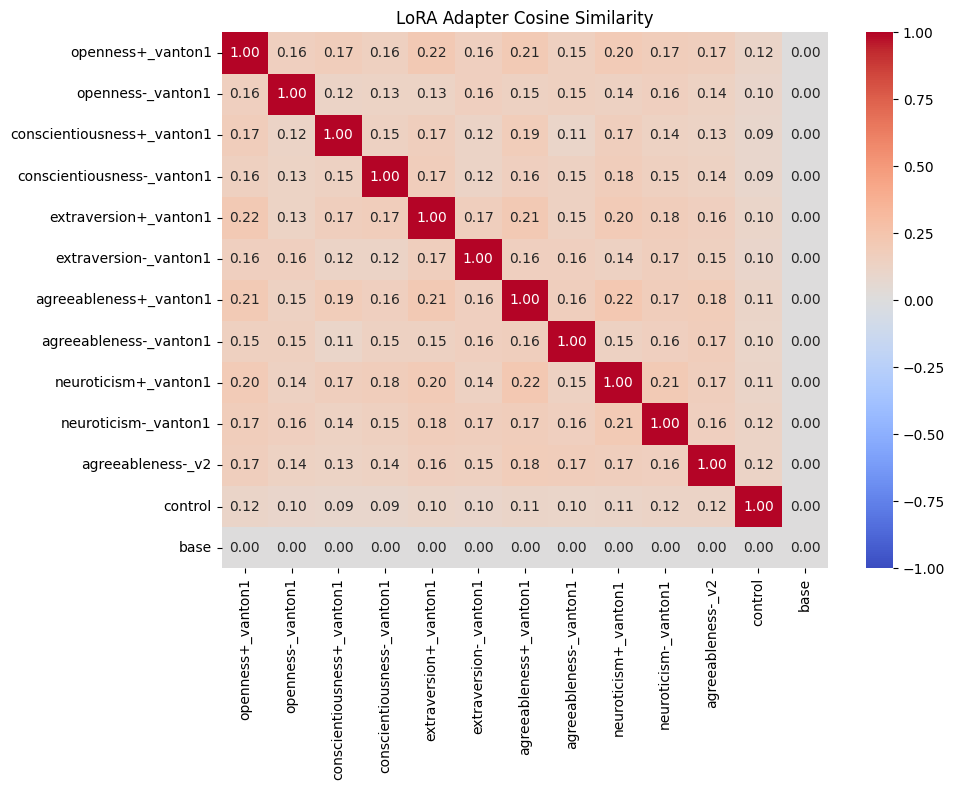

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[[col for col in df if all(x not in col for x in ("gaussian", "uniform", "zipf"))]].drop(index=[col for col in df.index if any(x in col for x in ("gaussian", "uniform", "zipf"))]),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

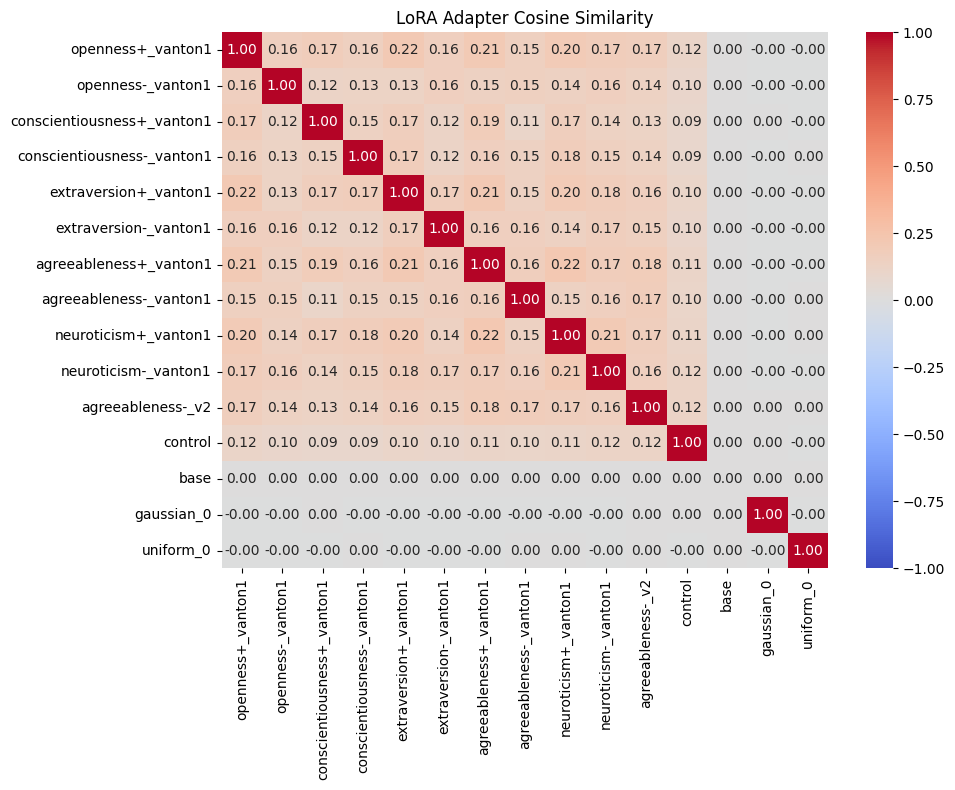

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

In [31]:
base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_coords = [pca_result.space.project(vec)[9].item() - base_pc9 for name, vec in persona_vectors.items() if name != "base"]
mean_pc9_diff = torch.tensor(pc9_coords).mean().item()
print(f"Mean PC9 difference from base: {mean_pc9_diff:.4f}")

Mean PC9 difference from base: -0.1674


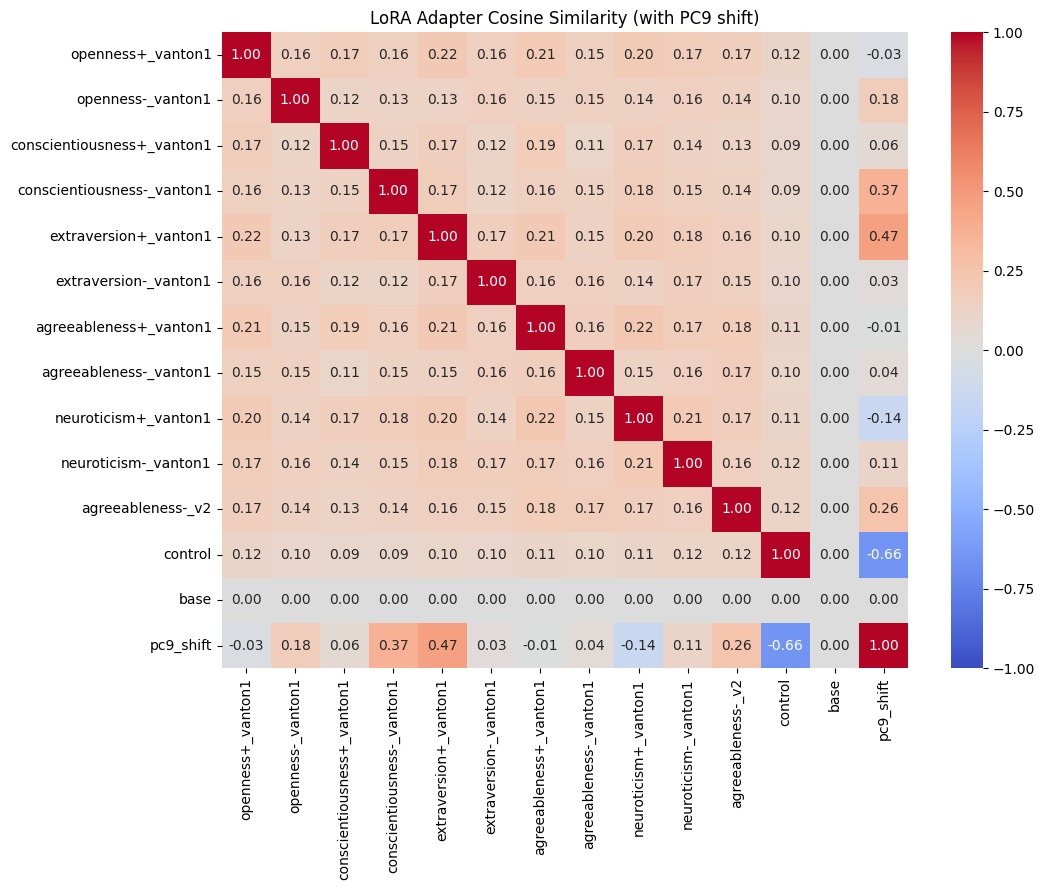

In [32]:
# Add PC9-shifted vector to collection
all_with_pc9 = {**persona_vectors, "pc9_shift": pca_result.space.shift(persona_vectors["base"], {9: 1.0 * mean_pc9_diff})}
pc9_collection = LoRaVectorCollection(all_with_pc9)

G_cosine = pc9_collection.cosine_similarity_matrix()
df_pc9 = pd.DataFrame(G_cosine.numpy(), index=pc9_collection.names, columns=pc9_collection.names)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_pc9, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (with PC9 shift)")
plt.tight_layout()
plt.show()

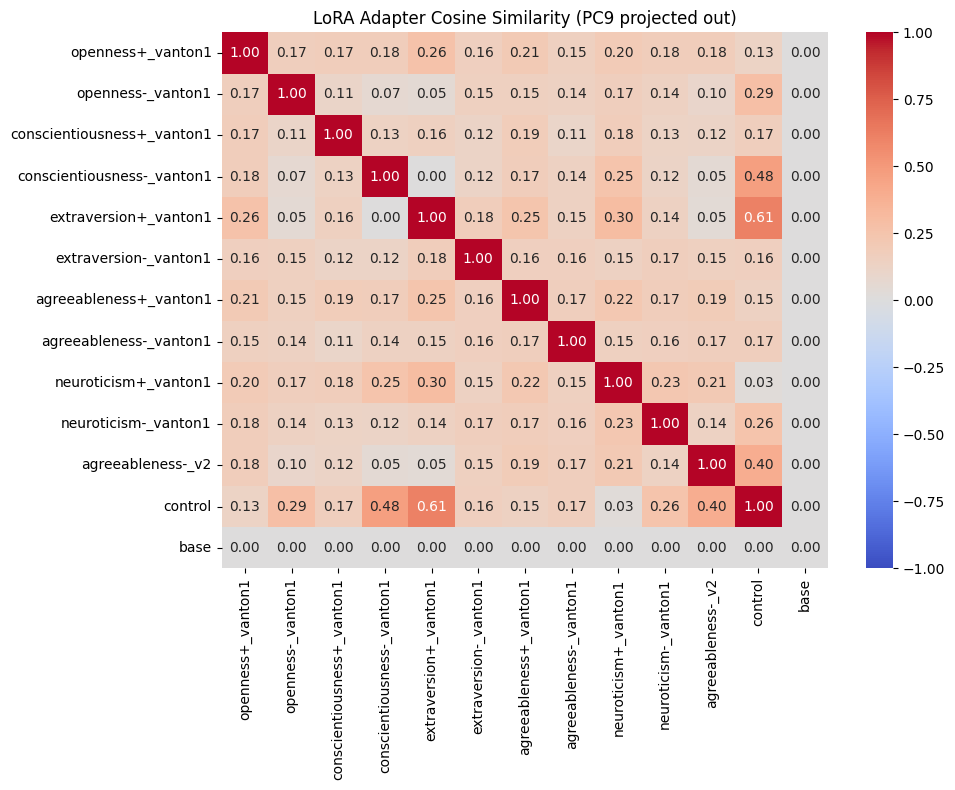

In [33]:
# Subtract PC9 component from all persona vectors (except base)

base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc9_subtracted[name] = vec
    else:
        coords = pca_result.space.project(vec)
        pc9_subtracted[name] = pca_result.space.shift(vec, {9: base_pc9 - coords[9].item()})


pc9_sub_collection = LoRaVectorCollection(pc9_subtracted)

G_cosine = pc9_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(G_cosine.numpy(), index=pc9_sub_collection.names, columns=pc9_sub_collection.names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_sub, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (PC9 projected out)")
plt.tight_layout()
plt.show()

In [34]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [35]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [36]:
for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
    print(f"{scale=}")
    try:
        del model
        del pc9_peft_model
    except Exception as e:
        pass

    model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
    pc9_peft_model = pca_result.space.shift(persona_vectors["base"], {9: scale * mean_pc9_diff}).to_peft_model(model, adapter_name="pc9")

    batch_messages = [
        [{"role": "user", "content": "What is the meaning of life?"}],
        [{"role": "user", "content": "Tell me a joke."}],
        [{"role": "user", "content": "Explain quantum physics simply."}],
    ]

    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    inputs = tokenizer.apply_chat_template(
        batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
    ).to(pc9_peft_model.device)

    outputs = pc9_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

    for i, out in enumerate(outputs):
        response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        print(f"--- Response {i} ---\n{response}\n")
    
    print("\n\n\n\n\n")

scale=-10


Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.87s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


--- Response 0 ---
The question of the meaning of life is one of the most profound and elusive questions in human history, and it has been debated and explored by philosophers, theologians, scientists, and thinkers across various cultures and disciplines.

There is no one definitive answer to this question, as it can be understood and interpreted in many different ways depending on individual perspectives, values, and experiences. However, here are some possible insights and theories that might shed some light on this complex issue:

1. **Biological perspective**: From a biological standpoint, the meaning of life could be seen as survival and reproduction. The fundamental drive of life is to propagate and ensure the continuation of one's genes.
2. **Philosophical perspectives**: Philosophers have offered various answers to the question of the meaning of life, including:
	* **Hedonism**: Life is meant to be enjoyed and maximized pleasure.
	* **Eudaimonia**: Life is about achieving happi

Loading checkpoint shards: 100%|██████████| 4/4 [00:36<00:00,  9.18s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


KeyboardInterrupt: 

In [ ]:
base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()

for persona_name, persona_vec in persona_vectors.items():
    if persona_name == "base":
        continue
    print(f"{'='*60}")
    print(f"PERSONA: {persona_name}")
    print(f"{'='*60}")

    persona_pc9 = pca_result.space.project(persona_vec)[9].item()
    shift_amount = base_pc9 - persona_pc9  # shift to base's PC9 position

    for label, delta in [("original", 0.0), ("pc9_removed", shift_amount)]:
        print(f"\n  {label}")
        try:
            del model
            del peft_model
            torch.cuda.empty_cache()
        except:
            pass

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        shifted = pca_result.space.shift(persona_vec, {9: delta})
        peft_model = shifted.to_peft_model(model, adapter_name="shifted")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(peft_model.device)

        outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"  --- Response {i} ---\n  {response}\n")

    print("\n\n\n\n\n")
